In [64]:
import pandas as pd

df = pd.read_csv('data_housing/Housing.csv')
print(df.shape)
df.head()

(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [65]:
def detect_problem_type(y):
    if y.dtype == 'object':
        return 'classification'
    unique_ratio = y.nunique() / len(y)
    if y.nunique() <= 20 or unique_ratio < 0.05:
        return 'classification'
    else:
        return 'regression'

In [66]:
import numpy as np
import pandas as pd


def maybe_log_transform(df, target_col, problem_type, skew_threshold=1.0):
    # Log transform only applies to numeric targets in REGRESSION tasks
    if problem_type != "regression" or not pd.api.types.is_numeric_dtype(
        df[target_col]
    ):
        print(
            f"Target '{target_col}' is categorical/non-numeric or a classification task. Skipping log transform."
        )
        return df, target_col, False

    # Check skewness safely on numeric regression target
    skew = df[target_col].skew()

    if skew > skew_threshold:
        print(f"Target is skewed ({skew:.2f}) → applying log transform.")
        log_col = f"{target_col}_log"
        df[log_col] = np.log1p(df[target_col])
        return df, log_col, True
    else:
        print(f"Target skewness ({skew:.2f}) is acceptable. No log transform needed.")
        return df, target_col, False

In [67]:
target_col = input("Enter the target column name: ")

# 1. Detect problem type first
problem_type = detect_problem_type(df[target_col])
print(f"Detected problem type: {problem_type}")

# 2. Pass problem_type into the function call
df, target_col, was_log_transformed = maybe_log_transform(
    df, target_col, problem_type
)
print(f"Using target column: {target_col}")

Detected problem type: regression
Target is skewed (1.21) → applying log transform.
Using target column: price_log


In [68]:
def validate_inputs(df, target_col):
    errors = []
    warnings = []
    
    if target_col not in df.columns:
        errors.append(f"Target column '{target_col}' not found in dataset. Available columns: {list(df.columns)}")
        return errors, warnings
    
    if len(df) < 20:
        errors.append(f"Dataset has only {len(df)} rows — too small for a reliable train/test split.")
    
    if df[target_col].nunique() <= 1:
        errors.append(f"Target column '{target_col}' has only {df[target_col].nunique()} unique value(s) — nothing to predict.")
    
    feature_cols = [c for c in df.columns if c != target_col]
    if len(feature_cols) == 0:
        errors.append("No feature columns found besides the target column.")
    
    null_pct = df.isnull().mean() * 100
    mostly_null_cols = null_pct[null_pct > 90].index.tolist()
    if mostly_null_cols:
        warnings.append(f"Columns over 90% missing (will likely be dropped): {mostly_null_cols}")
    
    target_nulls = df[target_col].isnull().sum()
    if target_nulls > 0:
        warnings.append(f"Target column has {target_nulls} missing values — these rows will need to be dropped before training.")
    
    return errors, warnings

errors, warnings = validate_inputs(df, target_col)

if errors:
    print("❌ Cannot proceed:")
    for e in errors:
        print(f"  - {e}")
else:
    if warnings:
        print("⚠️ Warnings (proceeding anyway):")
        for w in warnings:
            print(f"  - {w}")
    print("✅ Validation passed — continuing pipeline")

✅ Validation passed — continuing pipeline


In [69]:
def clean_data(df):
    report = {'initial_shape': df.shape, 'actions_taken': []}
    
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        df = df.drop_duplicates()
        report['actions_taken'].append(f"Removed {dup_count} duplicate rows")
    
    empty_cols = df.columns[df.isnull().all()]
    if len(empty_cols) > 0:
        df = df.drop(columns=empty_cols)
        report['actions_taken'].append(f"Dropped empty columns: {list(empty_cols)}")
    
    id_cols = [col for col in df.columns if col.lower() in ['id', 'patient_id', 'index']]
    if id_cols:
        df = df.drop(columns=id_cols)
        report['actions_taken'].append(f"Dropped ID columns: {id_cols}")
    
    report['final_shape'] = df.shape
    return df, report

In [70]:
df, report = clean_data(df)

In [71]:
df.info()
print(df[target_col].isnull().sum())
print(df[target_col].unique())

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              545 non-null    int64  
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    str    
 6   guestroom         545 non-null    str    
 7   basement          545 non-null    str    
 8   hotwaterheating   545 non-null    str    
 9   airconditioning   545 non-null    str    
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    str    
 12  furnishingstatus  545 non-null    str    
 13  price_log         545 non-null    float64
dtypes: float64(1), int64(6), str(7)
memory usage: 59.7 KB
0
[16.40327467 16.32103658 16.31817534 16.25000081 16.19967573 16.13298436
 16.10501051 16.0978

In [72]:


# Cell: define the function (if not already defined)
def encode_categoricals(df, target_col):
    feature_cols = [col for col in df.columns if col != target_col]
    categorical_feature_cols = df[feature_cols].select_dtypes(include=['object', 'str']).columns.tolist()
    if categorical_feature_cols:
        print(f"One-hot encoding: {categorical_feature_cols}")
        df = pd.get_dummies(df, columns=categorical_feature_cols)
    else:
        print("No categorical features to encode.")
    
    return df

# Cell: call it
df = encode_categoricals(df, target_col)

One-hot encoding: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [73]:
def check_imbalance(df, target_col):
    counts = df[target_col].value_counts()
    percentages = df[target_col].value_counts(normalize=True) * 100
    
    print("Class counts:")
    print(counts)
    print("\nClass percentages:")
    print(percentages.round(2))
    
    minority_pct = percentages.min()
    if minority_pct < 10:
        print(f"\n⚠️ Severe imbalance detected (minority class: {minority_pct:.1f}%). Consider resampling or class_weight='balanced'.")
    elif minority_pct < 30:
        print(f"\n⚠️ Mild-to-moderate imbalance (minority class: {minority_pct:.1f}%). Use class_weight='balanced' and check precision/recall, not just accuracy.")
    else:
        print(f"\n Classes are reasonably balanced (minority class: {minority_pct:.1f}%).")
    
    return counts


In [74]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def encode_target(df, target_col):
    df_copy = df.copy()
    
    # Safely checks if the column is NOT numeric (catches str, object, category)
    if not pd.api.types.is_numeric_dtype(df_copy[target_col]):
        le = LabelEncoder()
        df_copy[target_col] = le.fit_transform(df_copy[target_col])
        
    return df_copy



In [75]:
def check_outliers(df, target_col):
    feature_cols = [col for col in df.columns if col != target_col]
    # Only check numeric columns, excluding booleans (from one-hot encoding)
    numeric_cols = df[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    outlier_summary = {}
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        if len(outliers) > 0:
            outlier_summary[col] = len(outliers)
    
    print(f"Columns with outliers (IQR method):")
    for col, count in sorted(outlier_summary.items(), key=lambda x: -x[1]):
        print(f"  {col}: {count} outliers")
    
    return outlier_summary

outlier_summary = check_outliers(df, target_col)

Columns with outliers (IQR method):
  stories: 41 outliers
  price: 15 outliers
  area: 12 outliers
  bedrooms: 12 outliers
  parking: 12 outliers
  bathrooms: 1 outliers


In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

def generate_eda_plots(df, target_col, problem_type):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    feature_cols = [c for c in numeric_cols if c != target_col]

    # 1. Correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    # 2. Distribution of each numeric feature
    n_cols = 4
    n_rows = -(-len(feature_cols) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
    axes = axes.flatten()
    for i, col in enumerate(feature_cols):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(col, fontsize=10)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

    # 3. Feature vs target — adapts by problem type
    top_features = df[numeric_cols].corr()[target_col].abs().sort_values(ascending=False).index[1:7]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for i, col in enumerate(top_features):
        if problem_type == 'classification':
            sns.boxplot(x=df[target_col], y=df[col], ax=axes[i])
        else:
            sns.scatterplot(x=df[col], y=df[target_col], alpha=0.5, ax=axes[i])
        axes[i].set_title(f'{col} vs {target_col}', fontsize=10)
    plt.tight_layout()
    plt.show()

In [77]:
if was_log_transformed:
    original_target = target_col.replace('_log', '')
    X = df.drop(columns=[target_col, original_target])
else:
    X = df.drop(columns=[target_col])

y = df[target_col]

print(X.shape)
print(y.shape)

(545, 20)
(545,)


In [78]:
problem_type = detect_problem_type(y)
print(f"Detected problem type: {problem_type}")

if problem_type == 'classification':
    check_imbalance(df, target_col)
    df = encode_target(df, target_col)

Detected problem type: regression


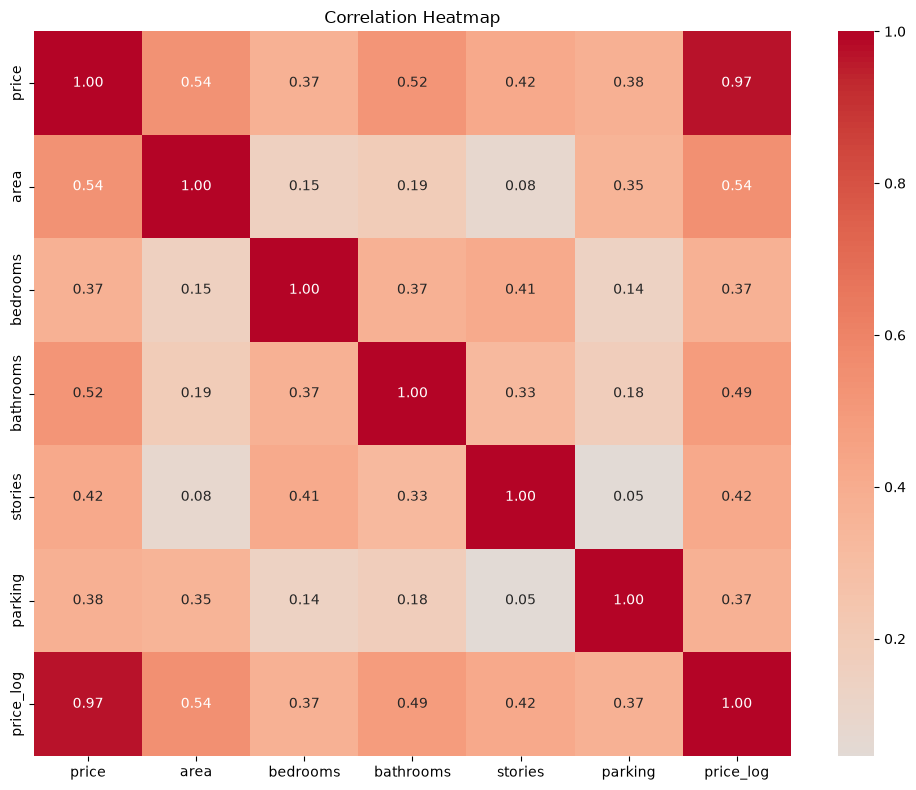

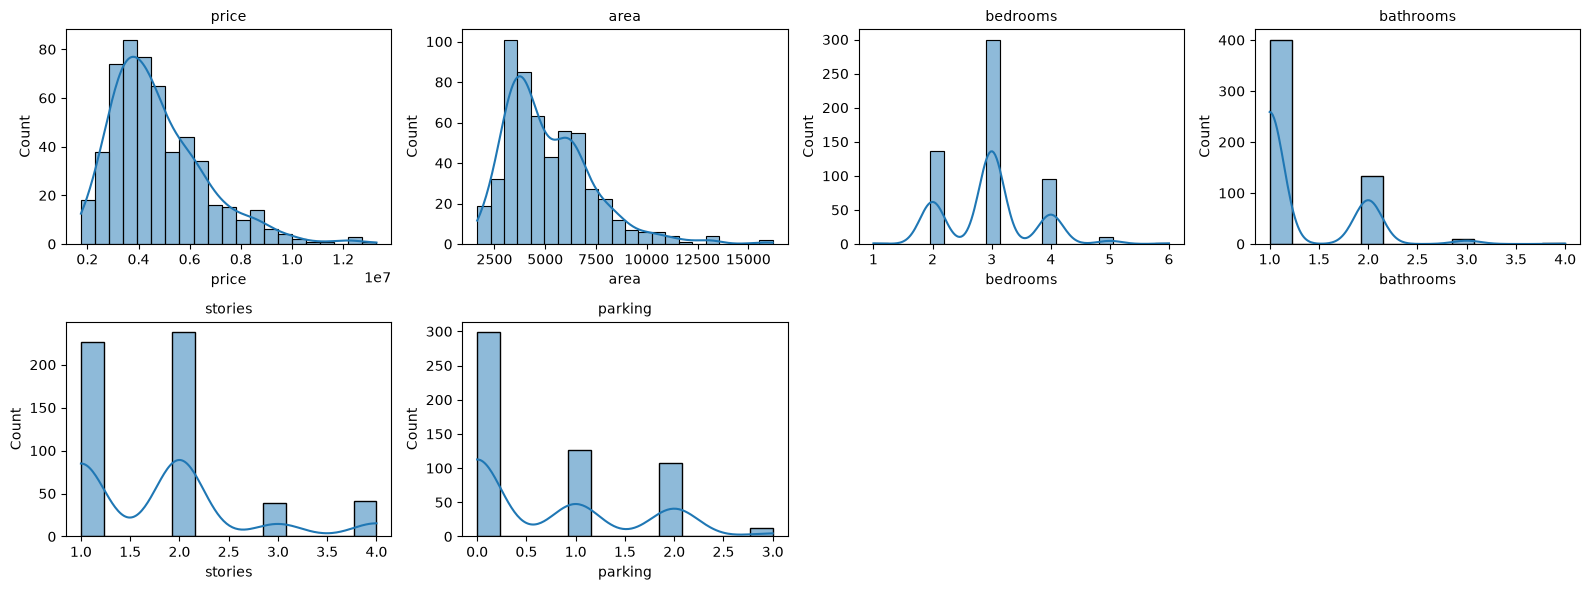

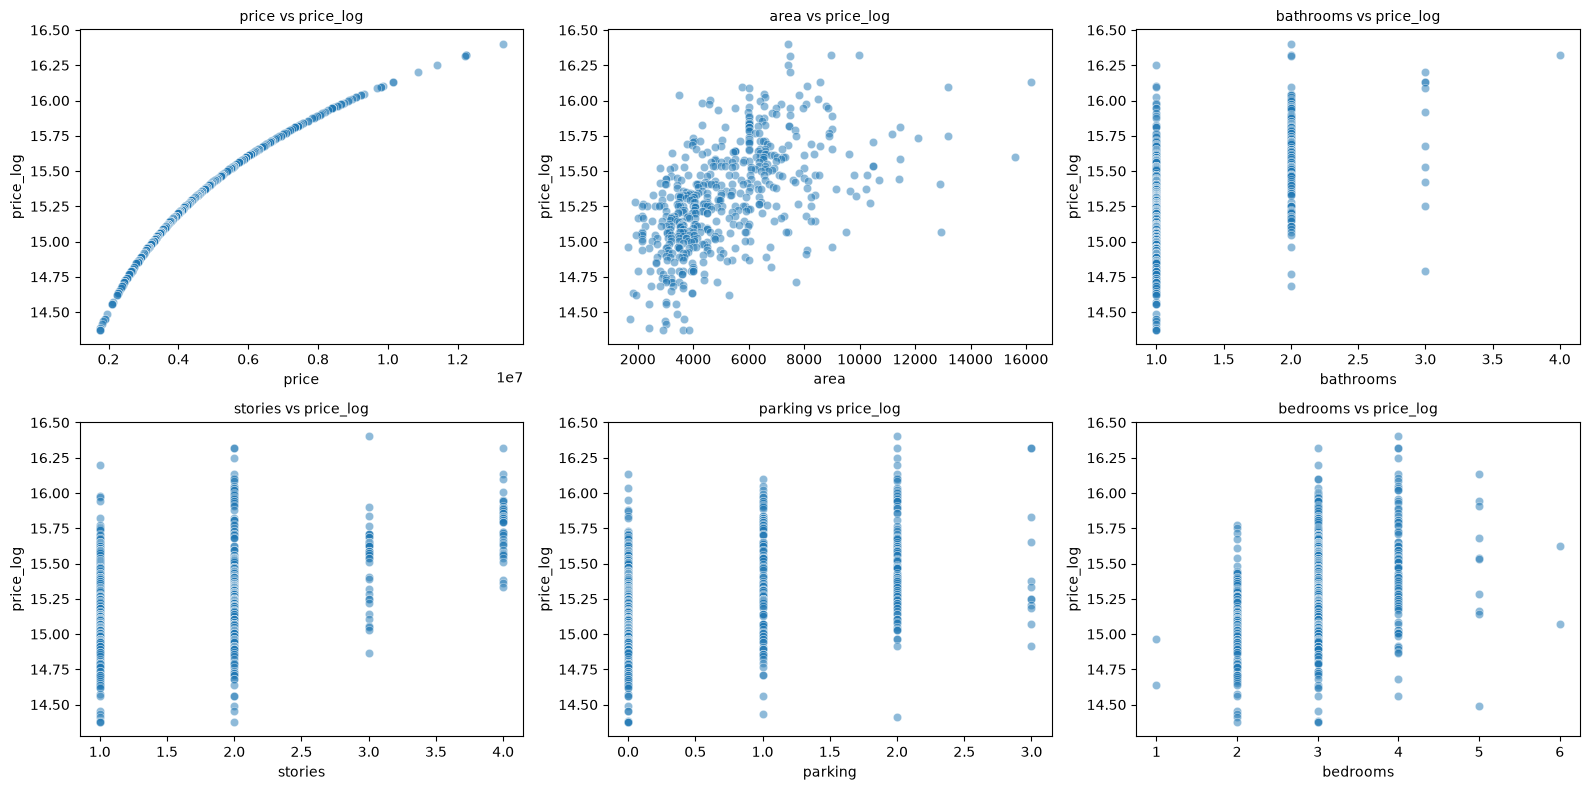

In [79]:
generate_eda_plots(df, target_col, problem_type)

In [80]:
from sklearn.model_selection import train_test_split

def split_data(X, y, test_size=0.2):
    problem_type = detect_problem_type(y)
    if problem_type == 'classification':
        return train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    else:
        return train_test_split(X, y, test_size=test_size, random_state=42)

In [81]:
X_train, X_test, y_train, y_test = split_data(X, y)
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (436, 20)
Test shape: (109, 20)


In [82]:
def choose_scaler(outlier_summary, total_features):
    outlier_ratio = len(outlier_summary) / total_features
    if outlier_ratio >= 0.3:
        print(
            f"Significant outliers detected ({len(outlier_summary)}/{total_features} features) → using RobustScaler"
        )
        from sklearn.preprocessing import RobustScaler

        return RobustScaler()
    else:
        print("Few outliers detected → using StandardScaler")
        from sklearn.preprocessing import StandardScaler

        return StandardScaler()


scaler = choose_scaler(outlier_summary, total_features=X.shape[1])

Significant outliers detected (6/20 features) → using RobustScaler


In [83]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")
print(X_train_scaled.shape)
print(X_test_scaled.shape)

Scaling complete
(436, 20)
(109, 20)


In [84]:
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.linear_model import HuberRegressor, LogisticRegression, Ridge
from sklearn.svm import SVC, SVR


def get_default_models(problem_type):
    if problem_type == "classification":
        return {
            "Logistic Regression": LogisticRegression(
                class_weight="balanced", random_state=42
            ),
            "Random Forest": RandomForestClassifier(
                class_weight="balanced", random_state=42
            ),
            "Gradient Boosting": GradientBoostingClassifier(random_state=42),
            "Support Vector Classifier": SVC(
                class_weight="balanced", random_state=42
            ),
        }
    else:
        return {
            "Ridge Regression": Ridge(alpha=1.0),
            "Huber Regression (Robust)": HuberRegressor(max_iter=1000),
            "Support Vector Regressor": SVR(C=1.0, epsilon=0.1),
            "Random Forest (Tuned)": RandomForestRegressor(
                n_estimators=100, max_depth=5, random_state=42
            ),
            "Gradient Boosting (Tuned)": GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                random_state=42,
            ),
        }

In [85]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
)

def evaluate_model(y_test, y_pred, problem_type='classification', show_confusion_matrix=True):
    results = {}
    
    if problem_type == 'classification':
        unique_classes = np.unique(y_test)
        is_binary = len(unique_classes) == 2
        avg_method = 'binary' if is_binary else 'weighted'
        
        results['accuracy'] = accuracy_score(y_test, y_pred)
        results['precision'] = precision_score(y_test, y_pred, average=avg_method, zero_division=0)
        results['recall'] = recall_score(y_test, y_pred, average=avg_method, zero_division=0)
        results['f1'] = f1_score(y_test, y_pred, average=avg_method, zero_division=0)
        
        if show_confusion_matrix:
            print("Confusion Matrix:")
            print(confusion_matrix(y_test, y_pred))
            
    else:  # Regression
        results['mae'] = mean_absolute_error(y_test, y_pred)
        results['rmse'] = np.sqrt(mean_squared_error(y_test, y_pred))
        results['r2'] = r2_score(y_test, y_pred)
        
    return results

In [86]:
models = get_default_models(problem_type)
all_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Safely convert both back to original price scale
    if was_log_transformed:
        y_pred_eval = np.expm1(y_pred)
        y_test_eval = np.expm1(y_test.values)  # Convert Series to numpy array
    else:
        y_pred_eval = y_pred
        y_test_eval = y_test

    metrics = evaluate_model(
        y_test_eval, y_pred_eval, problem_type, show_confusion_matrix=False
    )
    metrics["model"] = name
    all_results.append(metrics)
    trained_models[name] = model

results_df = pd.DataFrame(all_results)
print(results_df)

            mae          rmse        r2                      model
0  9.597773e+05  1.315262e+06  0.657752           Ridge Regression
1  9.794419e+05  1.332461e+06  0.648743  Huber Regression (Robust)
2  1.020190e+06  1.410860e+06  0.606193   Support Vector Regressor
3  1.068345e+06  1.478416e+06  0.567577      Random Forest (Tuned)
4  9.737644e+05  1.350297e+06  0.639276  Gradient Boosting (Tuned)


In [87]:
def recommend_model(results_df, trained_models, problem_type, priority=None):
    if priority is None:
        priority = 'f1' if problem_type == 'classification' else 'r2'
    
    valid_priorities = {
        'classification': ['accuracy', 'precision', 'recall', 'f1'],
        'regression': ['mae', 'rmse', 'r2']
    }
    
    if priority not in valid_priorities[problem_type]:
        raise ValueError(f"For {problem_type}, priority must be one of {valid_priorities[problem_type]}")
    
    # For MAE/RMSE, lower is better. For everything else, higher is better.
    ascending = priority in ['mae', 'rmse']
    best_row = results_df.sort_values(priority, ascending=ascending).iloc[0]
    best_model_name = best_row['model']
    
    print(f"Recommended model based on '{priority}': {best_model_name}")
    for col in results_df.columns:
        if col != 'model':
            print(f"  {col}: {best_row[col]:.4f}")
    
    return trained_models[best_model_name]

In [88]:
best_model = recommend_model(results_df, trained_models, problem_type, priority='r2')

Recommended model based on 'r2': Ridge Regression
  mae: 959777.2626
  rmse: 1315262.1048
  r2: 0.6578


In [89]:
import joblib

def save_model(model, scaler, feature_columns, problem_type, was_log_transformed, filepath):
    bundle = {
        'model': model,
        'scaler': scaler,
        'feature_columns': feature_columns,
        'problem_type': problem_type,
        'was_log_transformed': was_log_transformed
    }
    joblib.dump(bundle, filepath)
    print(f"Model saved to {filepath}")

def load_model(filepath):
    bundle = joblib.load(filepath)
    print(f"Model loaded from {filepath}")
    return bundle

In [91]:
def predict_single(model, scaler, sample_dict, feature_columns, was_log_transformed=False):
    sample_df = pd.DataFrame([sample_dict])
    
    missing_cols = set(feature_columns) - set(sample_df.columns)
    if missing_cols:
        raise ValueError(f"Missing required features: {missing_cols}")
    
    sample_df = sample_df[feature_columns]
    sample_scaled = scaler.transform(sample_df)
    
    prediction = model.predict(sample_scaled)[0]
    if was_log_transformed:
        prediction = np.expm1(prediction)
    
    result = {'prediction': float(prediction)}
    
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(sample_scaled)[0]
        result['confidence'] = float(proba.max())
        result['class_probabilities'] = [float(p) for p in proba]
    
    return result

In [93]:
def get_feature_importance(model, feature_names):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = abs(model.coef_).flatten()
    else:
        return None
    return sorted(zip(feature_names, importances), key=lambda x: -x[1])

In [96]:
# --- Example: full prediction workflow ---

# 1. Save the trained model
save_model(best_model, scaler, X_train.columns.tolist(), problem_type, was_log_transformed, 'model.joblib')

# 2. Load it back (simulates a fresh session)
bundle = load_model('model.joblib')

# 3. Predict on a new sample
sample_row = X_test.iloc[0].to_dict()
result = predict_single(bundle['model'], bundle['scaler'], sample_row, bundle['feature_columns'], bundle['was_log_transformed'])
print(f"Prediction: {result}")

# 4. Explain the prediction with feature importance
importance = get_feature_importance(bundle['model'], bundle['feature_columns'])
if importance:
    print("\nTop 5 most important features:")
    for name, score in importance[:5]:
        print(f"  {name}: {score:.4f}")

Model saved to model.joblib
Model loaded from model.joblib
Prediction: {'prediction': 4516243.207909433}

Top 5 most important features:
  bathrooms: 0.1850
  area: 0.1324
  stories: 0.0827
  airconditioning_yes: 0.0786
  airconditioning_no: 0.0786
